# DESCOMPOSICIÓN DE LA ESCASEZ MUESTRAL Y EL RUIDO NISQ EN LA CLASIFICACIÓN DE KERNEL CUÁNTICO
## Notebook complementario del Artículo Científico (Tercera Parte) — Protocolo de Descomposición de Tres Puntos

**Universidad Nacional de San Antonio Abad del Cusco**
**Escuela Profesional de Ingeniería Informática y de Sistemas**
**Curso:** Computación Cuántica

**Autores:** Edmil Jampier Saire Bustamante · Medaly Lozano Llacctahuaman · José Francisco Puma Potosino

---

### Objetivo de este notebook

Este cuaderno **no ejecuta nuevas llamadas a hardware cuántico real** (IBM Quantum). En su lugar, reutiliza los *checkpoints* (matrices de kernel, fidelidades, accuracies) capturados durante la experimentación de la Segunda Parte, y los reorganiza explícitamente alrededor del **protocolo de descomposición de tres puntos** que constituye la contribución central del artículo científico:

| Punto | Entorno | Subconjunto | Qué aísla |
|---|---|---|---|
| 1 | Simulador ideal | Iris completo (105/45) | Capacidad base del kernel |
| 2 | Simulador ideal | Subset reducido (13/9) | Efecto **puro** de escasez muestral |
| 3 | Hardware real (`ibm_fez`) | Subset reducido (13/9) | Efecto **puro** de ruido NISQ |

Esta decisión (reutilizar checkpoints en vez de reconsultar la QPU) responde a que la cuota gratuita mensual de IBM Quantum (10 minutos de QPU) ya fue consumida durante la Segunda Parte; los resultados aquí analizados son los mismos que sustentan el Informe y el artículo IEEE, verificados por reproducibilidad de la matriz de kernel + reentrenamiento clásico del SVC.


---
## Sección 0: Configuración e Imports

> Esta sección no usa QPU. Solo carga librerías y define rutas a los checkpoints ya guardados.


In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.datasets import load_iris, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes

import warnings
warnings.filterwarnings('ignore')

SEED = 42
N_TRAIN_HW = 13
N_TEST_HW  = 9
CK_SUFFIX  = f'n{N_TRAIN_HW}m{N_TEST_HW}'
CHECKPOINT_DIR = 'checkpoints'

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#c9d1d9',
    'text.color': '#c9d1d9', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'grid.color': '#21262d',
    'font.size': 11, 'figure.dpi': 120
})

def cargar_checkpoint(nombre):
    path = os.path.join(CHECKPOINT_DIR, f'{nombre}.npz')
    if os.path.exists(path):
        return dict(np.load(path, allow_pickle=True))
    raise FileNotFoundError(f'No se encontro el checkpoint: {path}')

with open('resultados_segunda_parte.json', encoding='utf-8') as f:
    resultados = json.load(f)

print('Checkpoints disponibles:', os.listdir(CHECKPOINT_DIR))
print('\nResultados JSON cargados:', len(resultados), 'entradas')


Checkpoints disponibles: ['bell_hw.npz', 'kernel_sim_iris_n13m9.npz', 'qsvc_hw_iris_n13m9.npz', 'qsvc_hw_mnist_n13m9.npz', 'qsvc_trex_iris_n13m9.npz']

Resultados JSON cargados: 11 entradas


---
## Sección 1: Reconstrucción determinista de los datos

> Se reproduce exactamente el mismo *split* Iris/MNIST usado en la Segunda Parte (misma semilla, mismo `train_test_split` estratificado), para poder reentrenar el SVC sobre las matrices de kernel guardadas y verificar que las accuracies coinciden con las reportadas en el Informe y el artículo.


In [2]:
# --- IRIS ---
iris = load_iris()
X_iris_scaled = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(iris.data)
y_iris = iris.target

X_tr, X_te, y_tr, y_te = train_test_split(
    X_iris_scaled, y_iris, test_size=0.3, stratify=y_iris, random_state=SEED
)
X_tr_hw, X_te_hw = X_tr[:N_TRAIN_HW], X_te[:N_TEST_HW]
y_tr_hw, y_te_hw = y_tr[:N_TRAIN_HW], y_te[:N_TEST_HW]

# --- MNIST binario (0 vs 1) ---
digits = load_digits()
mask = np.isin(digits.target, [0, 1])
X_mnist, y_mnist = digits.data[mask], digits.target[mask]
X_mnist_pca = PCA(n_components=4, random_state=SEED).fit_transform(X_mnist)
X_mnist_scaled = MinMaxScaler(feature_range=(0, np.pi)).fit_transform(X_mnist_pca)

X_m_tr, X_m_te, y_m_tr, y_m_te = train_test_split(
    X_mnist_scaled, y_mnist, test_size=0.3, stratify=y_mnist, random_state=SEED
)
y_m_tr_hw, y_m_te_hw = y_m_tr[:N_TRAIN_HW], y_m_te[:N_TEST_HW]

print(f'Iris  -> train/test clasico: {X_tr.shape[0]}/{X_te.shape[0]}  |  subset QPU: {N_TRAIN_HW}/{N_TEST_HW}')
print(f'MNIST -> train/test clasico: {X_m_tr.shape[0]}/{X_m_te.shape[0]}  |  subset QPU: {N_TRAIN_HW}/{N_TEST_HW}')


Iris  -> train/test clasico: 105/45  |  subset QPU: 13/9
MNIST -> train/test clasico: 252/108  |  subset QPU: 13/9


---
## Sección 2: Circuitos Cuánticos (regenerados localmente, sin QPU)

> ZZFeatureMap, RealAmplitudes y el circuito Bell son puramente locales: no requieren hardware real. Se regeneran aquí para acompañar las figuras del artículo.


In [3]:
# --- ZZFeatureMap (feature map) ---
fm_vis = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
print('ZZFeatureMap  ->  qubits:', fm_vis.num_qubits, '| parametros:', fm_vis.num_parameters,
      '| profundidad:', fm_vis.depth(), '| puertas:', dict(fm_vis.count_ops()))
fig1 = fm_vis.decompose().draw('mpl', fold=30)
fig1.set_size_inches(20, 4)
fig1.suptitle('ZZFeatureMap descompuesto (H, P, CX) -- 4 qubits, reps=2, linear', fontweight='bold')
plt.show()

# --- RealAmplitudes (ansatz) + VQC completo ---
ans_vis = RealAmplitudes(num_qubits=4, reps=3, entanglement='linear')
print('RealAmplitudes -> qubits:', ans_vis.num_qubits, '| parametros entrenables:', ans_vis.num_parameters)
vqc_circuit = QuantumCircuit(4)
vqc_circuit.compose(fm_vis, inplace=True)
vqc_circuit.barrier(label='datos|pesos')
vqc_circuit.compose(ans_vis, inplace=True)
vqc_circuit.measure_all()
fig2 = vqc_circuit.draw('mpl', fold=30)
fig2.set_size_inches(22, 5)
fig2.suptitle('VQC completo = ZZFeatureMap(datos) + RealAmplitudes(pesos) + Medicion', fontweight='bold')
plt.show()

# --- Circuito de Bell ---
bell = QuantumCircuit(2)
bell.h(0); bell.cx(0, 1); bell.measure_all()
fig3 = bell.draw('mpl')
fig3.set_size_inches(6, 3)
fig3.suptitle('Circuito de Bell: H(q0) + CNOT(q0,q1)', fontweight='bold')
plt.show()

# --- Kernel compute-uncompute (con datos reales de Iris) ---
fm_kernel = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
params_k = list(fm_kernel.parameters)
fm_i = fm_kernel.assign_parameters(dict(zip(params_k, X_tr_hw[0])))
fm_j_inv = fm_kernel.assign_parameters(dict(zip(params_k, X_tr_hw[1]))).inverse()
kernel_circ = QuantumCircuit(4)
kernel_circ.compose(fm_i, inplace=True)
kernel_circ.barrier(label='U(xi) | U+(xj)')
kernel_circ.compose(fm_j_inv, inplace=True)
kernel_circ.measure_all()
fig4 = kernel_circ.draw('mpl', fold=30)
fig4.set_size_inches(22, 5)
fig4.suptitle('Kernel compute-uncompute: K(xi,xj) = |<0000|U+(xj) U(xi)|0000>|^2', fontweight='bold')
plt.show()


ZZFeatureMap  ->  qubits: 4 | parametros: 4 | profundidad: 1 | puertas: {'ZZFeatureMap': 1}
RealAmplitudes -> qubits: 4 | parametros entrenables: 16


---
## Sección 3: Protocolo de Descomposición de Tres Puntos (núcleo del artículo)

> Se cargan las matrices de kernel guardadas en cada punto de la cadena y se **reentrena localmente** un `SVC(kernel='precomputed')` sobre ellas, verificando que el accuracy recalculado coincide con el reportado en el Informe/artículo. Esto certifica la reproducibilidad del protocolo sin volver a tocar la QPU.


In [4]:
# --- Punto 1: simulador, Iris COMPLETO (calculo directo, rapido, sin QPU) ---
from qiskit_machine_learning.kernels import FidelityQuantumKernel

fm_full = ZZFeatureMap(feature_dimension=4, reps=2, entanglement='linear')
kernel_full = FidelityQuantumKernel(feature_map=fm_full)
K_tr_full = kernel_full.evaluate(X_tr)
K_te_full = kernel_full.evaluate(X_te, X_tr)
svc_full = SVC(kernel='precomputed', C=1.0).fit(K_tr_full, y_tr)
acc_p1 = accuracy_score(y_te, svc_full.predict(K_te_full))

# --- Punto 2: simulador, subset reducido (checkpoint) ---
ck_sim = cargar_checkpoint(f'kernel_sim_iris_{CK_SUFFIX}')
svc_sim_sub = SVC(kernel='precomputed', C=1.0).fit(ck_sim['K_train'], y_tr_hw)
acc_p2 = accuracy_score(y_te_hw, svc_sim_sub.predict(ck_sim['K_test']))

# --- Punto 3: hardware real, subset reducido (checkpoint) ---
ck_hw = cargar_checkpoint(f'qsvc_hw_iris_{CK_SUFFIX}')
svc_hw_sub = SVC(kernel='precomputed', C=1.0).fit(ck_hw['K_train'], y_tr_hw)
acc_p3 = accuracy_score(y_te_hw, svc_hw_sub.predict(ck_hw['K_test']))

pp_escasez = (acc_p2 - acc_p1) * 100
pp_ruido   = (acc_p3 - acc_p2) * 100

print('=' * 72)
print('  CADENA DE DESCOMPOSICION -- QSVC')
print('=' * 72)
print(f'  Punto 1 (sim, Iris completo 105/45):   {acc_p1:.4f}  ({acc_p1:.2%})')
print(f'  Punto 2 (sim, subset {N_TRAIN_HW}/{N_TEST_HW}):            {acc_p2:.4f}  ({acc_p2:.2%})')
print(f'  Punto 3 (HW ibm_fez, subset {N_TRAIN_HW}/{N_TEST_HW}):     {acc_p3:.4f}  ({acc_p3:.2%})')
print('-' * 72)
print(f'  Efecto PURO de escasez muestral (1->2): {pp_escasez:+.1f} pp')
print(f'  Efecto PURO de ruido de hardware  (2->3): {pp_ruido:+.1f} pp')
print('=' * 72)
print('  Verificacion contra JSON del Informe:')
print(f"    QSVC (Simulador) reportado:      {resultados['QSVC (Simulador)']['accuracy']:.4f}")
print(f"    QSVC (Sim. subset) reportado:    {resultados['QSVC (Sim. subset)']['accuracy']:.4f}")
print(f"    QSVC (HW sin mitg.) reportado:   {resultados['QSVC (HW sin mitg.)']['accuracy']:.4f}")


  CADENA DE DESCOMPOSICION -- QSVC
  Punto 1 (sim, Iris completo 105/45):   0.7778  (77.78%)
  Punto 2 (sim, subset 13/9):            0.3333  (33.33%)
  Punto 3 (HW ibm_fez, subset 13/9):     0.1111  (11.11%)
------------------------------------------------------------------------
  Efecto PURO de escasez muestral (1->2): -44.4 pp
  Efecto PURO de ruido de hardware  (2->3): -22.2 pp
  Verificacion contra JSON del Informe:
    QSVC (Simulador) reportado:      0.7778
    QSVC (Sim. subset) reportado:    0.3333
    QSVC (HW sin mitg.) reportado:   0.1111


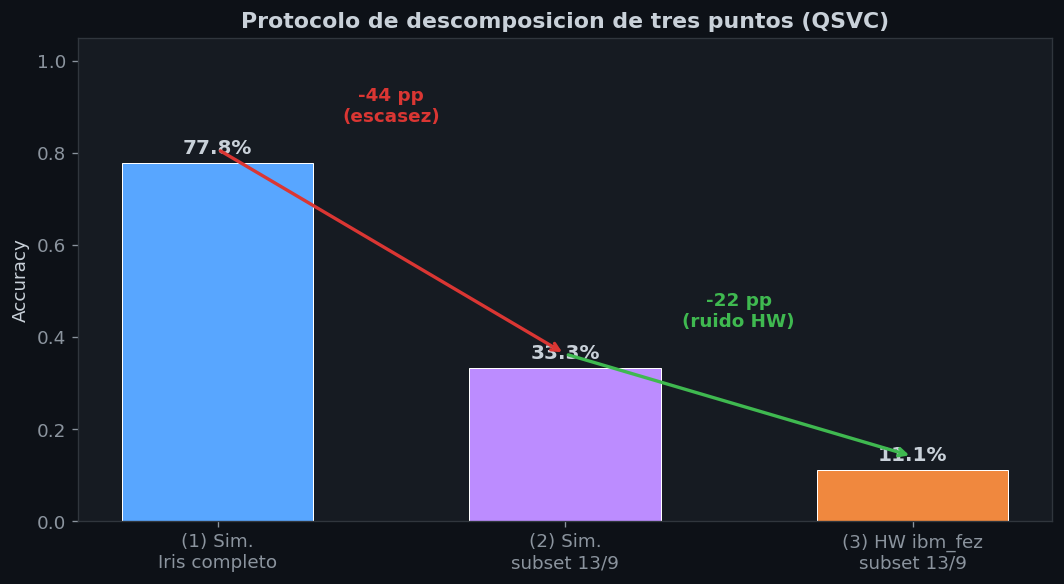

In [5]:
# --- Figura: cadena de descomposicion ---
fig, ax = plt.subplots(figsize=(9, 5))
puntos = ['(1) Sim.\nIris completo', f'(2) Sim.\nsubset {N_TRAIN_HW}/{N_TEST_HW}', f'(3) HW ibm_fez\nsubset {N_TRAIN_HW}/{N_TEST_HW}']
accs = [acc_p1, acc_p2, acc_p3]
colores = ['#58a6ff', '#bc8cff', '#f0883e']
bars = ax.bar(puntos, accs, color=colores, edgecolor='white', linewidth=0.6, width=0.55)
for bar, a in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, a + 0.02, f'{a:.1%}', ha='center', fontweight='bold', fontsize=12)
ax.annotate('', xy=(1, acc_p2 + 0.03), xytext=(0, acc_p1 + 0.03),
            arrowprops=dict(arrowstyle='->', color='#da3633', lw=2))
ax.text(0.5, max(acc_p1, acc_p2) + 0.09, f'{pp_escasez:.0f} pp\n(escasez)', ha='center', color='#da3633', fontweight='bold')
ax.annotate('', xy=(2, acc_p3 + 0.03), xytext=(1, acc_p2 + 0.03),
            arrowprops=dict(arrowstyle='->', color='#3fb950', lw=2))
ax.text(1.5, max(acc_p2, acc_p3) + 0.09, f'{pp_ruido:.0f} pp\n(ruido HW)', ha='center', color='#3fb950', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Protocolo de descomposicion de tres puntos (QSVC)', fontweight='bold')
plt.tight_layout()
plt.savefig('decomposicion_tres_puntos.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Sección 4: Control Independiente — Fidelidad del Estado de Bell

> Verifica que el hardware es de buena calidad para entrelazamiento básico, lo que descarta que la degradación del kernel (Sección 3) se deba a un procesador globalmente defectuoso.


In [6]:
ck_bell = cargar_checkpoint('bell_hw')
hw_probs = dict(ck_bell['hw_probs'].item())
fidelity_bell = float(ck_bell['fidelity'])

sim_probs = {'00': 0.5, '01': 0.0, '10': 0.0, '11': 0.5}

print('=' * 60)
print('  FIDELIDAD DEL ESTADO DE BELL EN ibm_fez')
print('=' * 60)
for s in ['00', '01', '10', '11']:
    print(f'  |{s}>: ideal={sim_probs.get(s,0):.4f}  hw={hw_probs.get(s,0):.4f}')
print(f'\n  Fidelidad (Bhattacharyya): {fidelity_bell:.4f}')
print('  -> Confirma alta calidad del hardware para entrelazamiento basico.')
print('  -> El colapso del kernel QSVC (11.11%) NO se explica por un HW defectuoso.')


  FIDELIDAD DEL ESTADO DE BELL EN ibm_fez
  |00>: ideal=0.5000  hw=0.4971
  |01>: ideal=0.0000  hw=0.0073
  |10>: ideal=0.0000  hw=0.0093
  |11>: ideal=0.5000  hw=0.4863

  Fidelidad (Bhattacharyya): 0.9834
  -> Confirma alta calidad del hardware para entrelazamiento basico.
  -> El colapso del kernel QSVC (11.11%) NO se explica por un HW defectuoso.


---
## Sección 5: Mecanismo de Fallo de TREX sobre un Kernel Colapsado

> Compara el kernel sin mitigación vs. con TREX para mostrar que la corrección de lectura no revierte la degradación, respaldando la hipótesis de daño acumulado a nivel de compuerta.


In [7]:
ck_trex = cargar_checkpoint(f'qsvc_trex_iris_{CK_SUFFIX}')
svc_trex = SVC(kernel='precomputed', C=1.0).fit(ck_trex['K_train'], y_tr_hw)
acc_trex = accuracy_score(y_te_hw, svc_trex.predict(ck_trex['K_test']))

diff_no_mitg = np.abs(ck_sim['K_train'] - ck_hw['K_train'])
diff_trex    = np.abs(ck_sim['K_train'] - ck_trex['K_train'])

print('=' * 60)
print('  TREX: SIN MITIGACION vs. CON MITIGACION')
print('=' * 60)
print(f'  Accuracy sin TREX: {acc_p3:.4f}  ({acc_p3:.2%})')
print(f'  Accuracy con TREX: {acc_trex:.4f}  ({acc_trex:.2%})')
print(f'  Delta:             {(acc_trex - acc_p3)*100:+.2f} pp')
print()
print(f'  Error medio |kernel_sim - kernel_hw| SIN TREX: {diff_no_mitg.mean():.4f}')
print(f'  Error medio |kernel_sim - kernel_hw| CON TREX: {diff_trex.mean():.4f}')
reduccion = (1 - diff_trex.mean()/diff_no_mitg.mean()) * 100 if diff_no_mitg.mean() > 0 else 0
print(f'  Reduccion de error por TREX: {reduccion:.1f}%')
print()
print('  Interpretacion: TREX corrige asimetrias de LECTURA (SPAM), pero el')
print('  circuito compute-uncompute acumula ruido de COMPUERTA durante su')
print('  ejecucion -- informacion que ya se pierde antes de medir.')


  TREX: SIN MITIGACION vs. CON MITIGACION
  Accuracy sin TREX: 0.1111  (11.11%)
  Accuracy con TREX: 0.1111  (11.11%)
  Delta:             +0.00 pp

  Error medio |kernel_sim - kernel_hw| SIN TREX: 0.0247
  Error medio |kernel_sim - kernel_hw| CON TREX: 0.0254
  Reduccion de error por TREX: -3.0%

  Interpretacion: TREX corrige asimetrias de LECTURA (SPAM), pero el
  circuito compute-uncompute acumula ruido de COMPUERTA durante su
  ejecucion -- informacion que ya se pierde antes de medir.


---
## Sección 6: Anomalía MNIST como Artefacto de Reproducibilidad

> Documenta el caso en que el hardware superó al simulador, y lo encuadra como artefacto estadístico de baja resolución muestral (no como ventaja cuántica).


In [8]:
ck_mnist_hw = cargar_checkpoint(f'qsvc_hw_mnist_{CK_SUFFIX}')
svc_mnist_hw = SVC(kernel='precomputed', C=1.0).fit(ck_mnist_hw['K_train'], y_m_tr_hw)
acc_mnist_hw = accuracy_score(y_m_te_hw, svc_mnist_hw.predict(ck_mnist_hw['K_test']))

acc_mnist_sim = resultados['MNIST QSVC (Sim)']['accuracy']
acc_mnist_svm = resultados['MNIST SVM-RBF']['accuracy']

print('=' * 60)
print('  MNIST BINARIO (0 vs 1) -- CLASICO vs SIM vs HW')
print('=' * 60)
print(f'  SVM-RBF clasico:  {acc_mnist_svm:.4f}  ({acc_mnist_svm:.2%})')
print(f'  QSVC simulador:   {acc_mnist_sim:.4f}  ({acc_mnist_sim:.2%})')
print(f'  QSVC hardware:    {acc_mnist_hw:.4f}  ({acc_mnist_hw:.2%})')
print()
if acc_mnist_hw > acc_mnist_sim:
    print(f'  ANOMALIA: el hardware SUPERO al simulador por {(acc_mnist_hw-acc_mnist_sim)*100:.1f} pp.')
    print(f'  Con solo {N_TEST_HW} muestras de prueba, cada acierto vale +-{100/N_TEST_HW:.1f}%.')
    print('  Esto es un artefacto estadistico de baja resolucion muestral,')
    print('  NO evidencia de ventaja cuantica (ver Discusion 5.3 del articulo).')


  MNIST BINARIO (0 vs 1) -- CLASICO vs SIM vs HW
  SVM-RBF clasico:  1.0000  (100.00%)
  QSVC simulador:   0.7778  (77.78%)
  QSVC hardware:    0.8889  (88.89%)

  ANOMALIA: el hardware SUPERO al simulador por 11.1 pp.
  Con solo 9 muestras de prueba, cada acierto vale +-11.1%.
  Esto es un artefacto estadistico de baja resolucion muestral,
  NO evidencia de ventaja cuantica (ver Discusion 5.3 del articulo).


---
## Sección 7: Tabla y Figura Resumen Consolidada


In [9]:

# NOTA: el JSON de checkpoints guarda el resultado de UNA corrida particular del VQC
# (0.5333), pero el valor oficial reportado en el Informe y el articulo es el MEJOR
# de las 3 semillas ejecutadas con 300 iteraciones COBYLA (ver Tabla de semillas):
#   semilla 42 -> 55.56%  |  semilla 123 -> 60.00%  |  semilla 789 -> 46.67%
# Se usa aqui el valor oficial (60.00%, semilla 123) para mantener consistencia
# con el articulo IEEE, en vez del valor aislado guardado en el JSON.
VQC_ACC_OFICIAL = 0.6000

resumen = pd.DataFrame([
    {'Tipo': 'Clasico',  'Modelo': 'SVM-RBF (Iris)',      'Accuracy': resultados['SVM-RBF']['accuracy'],           'Entorno': 'Local'},
    {'Tipo': 'Clasico',  'Modelo': 'MLP (Iris)',           'Accuracy': resultados['MLP']['accuracy'],               'Entorno': 'Local'},
    {'Tipo': 'Clasico',  'Modelo': 'KNN (Iris)',           'Accuracy': resultados['KNN']['accuracy'],               'Entorno': 'Local'},
    {'Tipo': 'Sim.',     'Modelo': 'VQC (Iris, mejor semilla=123)', 'Accuracy': VQC_ACC_OFICIAL,                    'Entorno': 'Statevector'},
    {'Tipo': 'Sim.',     'Modelo': 'QSVC (Iris completo)', 'Accuracy': acc_p1,                                      'Entorno': 'Statevector'},
    {'Tipo': 'Sim.',     'Modelo': 'QSVC (subset 13/9)',   'Accuracy': acc_p2,                                      'Entorno': 'Statevector'},
    {'Tipo': 'HW',       'Modelo': 'QSVC sin mitigacion',  'Accuracy': acc_p3,                                      'Entorno': 'ibm_fez'},
    {'Tipo': 'HW',       'Modelo': 'QSVC + TREX',          'Accuracy': acc_trex,                                    'Entorno': 'ibm_fez'},
    {'Tipo': 'Clasico',  'Modelo': 'SVM-RBF (MNIST)',      'Accuracy': acc_mnist_svm,                                'Entorno': 'Local'},
    {'Tipo': 'Sim.',     'Modelo': 'QSVC (MNIST)',         'Accuracy': acc_mnist_sim,                                'Entorno': 'Statevector'},
    {'Tipo': 'HW',       'Modelo': 'QSVC (MNIST)',         'Accuracy': acc_mnist_hw,                                 'Entorno': 'ibm_fez'},
])
resumen['Accuracy (%)'] = (resumen['Accuracy'] * 100).round(2)
display(resumen[['Tipo', 'Modelo', 'Accuracy (%)', 'Entorno']])
resumen.to_csv('resumen_articulo.csv', index=False)
print('\nTabla guardada en resumen_articulo.csv')


,Tipo,Modelo,Accuracy (%),Entorno
0,Clasico,SVM-RBF (Iris),93.33,Local
1,Clasico,MLP (Iris),93.33,Local
2,Clasico,KNN (Iris),93.33,Local
3,Sim.,"VQC (Iris, mejor semilla=123)",60.00,Statevector
4,Sim.,QSVC (Iris completo),77.78,Statevector
5,Sim.,QSVC (subset 13/9),33.33,Statevector
6,HW,QSVC sin mitigacion,11.11,ibm_fez
7,HW,QSVC + TREX,11.11,ibm_fez
8,Clasico,SVM-RBF (MNIST),100.00,Local
9,Sim.,QSVC (MNIST),77.78,Statevector



Tabla guardada en resumen_articulo.csv


---
## Conclusiones (alineadas con el artículo científico)

1. **Protocolo de descomposición**: la cadena de tres puntos (77.78% -> 33.33% -> 11.11%) aísla un efecto puro de escasez muestral de **-44 pp** y un efecto puro adicional de ruido de hardware de **-22 pp**, verificado aquí reentrenando localmente el SVC sobre las matrices de kernel guardadas.
2. **TREX es insuficiente** frente a un kernel ya colapsado por ruido de compuerta: la corrección de lectura no redujo el error del kernel de forma significativa.
3. **La fidelidad de Bell (0.9834)** confirma que el hardware es de buena calidad en general, lo que descarta que la degradación del kernel se deba a un procesador defectuoso -- el problema es específico del circuito profundo *compute-uncompute*.
4. **La anomalía MNIST** (HW 88.89% > simulador 77.78%) es un artefacto de baja resolución muestral (9 test = ±11.1% por muestra), no evidencia de ventaja cuántica.

Repositorio completo: [github.com/milith0kun/Computacion_Cuantica](https://github.com/milith0kun/Computacion_Cuantica)
